# Kinetic-Feature LOFO Baseline -- XGBoost + KNN

Curiosity check: how well do plain classical classifiers do at leave-one-chip-out
(LOFO) classification on `final_6_new`, trained purely on the precomputed *kinetic
features* per curve (Ct, sigmoid-fit params, asymmetry indices, ... -- the same
`config.LD_FEATURES` pool the existing late-fusion models draw from), rather than
on the raw curves the deep models see?

Two models x two feature sets, all four combinations run per held-out chip:
- **XGBoost** and **KNN** (`n_neighbors=10`, matching the existing pipeline's own
  `knn` model's hyperparameter choice -- though that model is raw-curve-based, not
  kinetic-feature-based).
- **top-10** (per-fold, train-only `mutual_info_classif` selection -- exactly what
  the main pipeline's own classical/late-fusion models use, via
  `04_cross_dataset_training.py`'s `_select_top_10_features`) vs. **all 38**
  `config.LD_FEATURES`.

Rows with a NaN in any feature actually used (top-10 or all-38, whichever combo is
being fit) are dropped rather than zero-filled -- a NaN kinetic feature (e.g. `Ct`
when a curve never crosses threshold) is informative-by-absence, not a real 0, and
zero-filling would bias both XGBoost's splits and KNN's distances.

This notebook only imports from the existing pipeline (`04_cross_dataset_training.py`,
aliased `cdt`) -- `combine_group`, `_derive_pool_labels`, `build_lofo_splits`,
`_select_top_10_features` -- exactly the functions the real LOFO training run itself
calls, so the fold definitions and pooled data match the real pipeline exactly. No
existing file is modified.

In [1]:
import sys
import importlib
import types
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import math
import xgboost as xgb


In [2]:
import os

try:
    # VS Code injects '__vsc_ipynb_file__' into the globals automatically
    notebook_path = globals().get('__vsc_ipynb_file__')
    if notebook_path:
        notebook_dir = os.path.dirname(os.path.dirname(notebook_path))
        os.chdir(notebook_dir)
except Exception as e:
    print(f"Could not change directory: {e}")

print("Current Working Directory:", os.getcwd())
%load_ext autoreload
%autoreload 2
import config

# Reuse 04's own data-loading/LOFO-split/feature-selection logic instead of
# reimplementing it, so this notebook always matches what the real training run
# actually sees (well exclusion, label mapping, LOFO fold definition, top-10
# mutual-info feature selection).
cdt = importlib.import_module("04_cross_dataset_training")

# 04_cross_dataset_training -> lstm_autoencoder_outlier -> outlier_utils, and
# outlier_utils.py does matplotlib.use('Agg') at import time (headless-safe for its
# own script use) -- this silently overrides the inline backend set in cell 1, since
# that import chain only just ran now. Re-assert it so plt.show() below still works.
%matplotlib inline


Current Working Directory: /vol/bitbucket/gk225/POC_DDM/gk_code/main



[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0



## 1. Configuration

In [3]:
GROUP_NAME = "final_6_new"
CURVE_TYPE = "ori_curve_sg_p4_norm"   # matches the deep-model LOFO tables' curve_type
EXP_FOLDER = config.FINAL_EXP_FOLDER


def short_name(folder):
    m = re.search(r'DDM_0(\d)', folder)
    return f'Chip 0{m.group(1)}' if m else folder.split('_U_', 1)[1]


def chip_sort_key(folder_or_label):
    m = re.search(r'DDM_0(\d)', folder_or_label)
    return int(m.group(1)) if m else folder_or_label


folder_names = sorted(config.CROSS_DATASET_GROUPS[GROUP_NAME], key=chip_sort_key)
exp_paths = [Path(EXP_FOLDER, name) for name in folder_names]

print(f"Group '{GROUP_NAME}' -> {len(folder_names)} chips:")
for n in folder_names:
    print(f"  - {n} ({short_name(n)})")


Group 'final_6_new' -> 6 chips:
  - D20260827_E00_C00_F4500KHz_U_DDM_01_final_final (Chip 01)
  - D20260827_E00_C00_F4500KHz_U_DDM_02_final_final (Chip 02)
  - D20260827_E00_C00_F4500KHz_U_DDM_03_final_final (Chip 03)
  - D20260827_E00_C00_F4500KHz_U_DDM_04_final_final (Chip 04)
  - D20260825_E00_C00_F4500KHz_U_DDM_05_01 (Chip 05)
  - D20260825_E00_C00_F4500KHz_U_DDM_06_02 (Chip 06)


## 2. Load pooled data + LOFO folds

`combine_group` pools every chip's kinetic features (+ curves, unused here) into
one table; `_derive_pool_labels` label-encodes targets and builds the
`np.nan_to_num`-cleaned `X_candidates_clean` matrix used only for feature
*selection* (matching existing pipeline behaviour exactly -- the NaN-row-dropping
used for the actual model fits below is separate, see section 3);
`build_lofo_splits` gives the exact one-chip-held-out splits the real LOFO run
trains on.

In [4]:
combined = cdt.combine_group(exp_paths, GROUP_NAME, curve_type=CURVE_TYPE)
assert combined is not None, "combine_group returned None -- check EXP_FOLDER/GROUP_NAME/CURVE_TYPE"

encoder, y_full, X_candidates_clean, *_ = cdt._derive_pool_labels(combined, types.SimpleNamespace(mtl=False))
class_names = list(encoder.classes_)
features_df = combined["features_df"]
print(f"Combined pool: {len(y_full)} samples, {len(class_names)} classes: {class_names}")
print(f"features_df: {features_df.shape[0]} rows x {features_df.shape[1]} columns")

lofo_splits_raw = cdt.build_lofo_splits(combined["dataset_id"])
lofo_splits = {f"lofo_{name}": lofo_splits_raw[f"lofo_{name}"] for name in folder_names}
print(f"\n{len(lofo_splits)} LOFO folds (chip order): {[short_name(k.replace('lofo_', '')) for k in lofo_splits]}")


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1686 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_01_final_final


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1828 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_02_final_final


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1842 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_03_final_final


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1774 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_04_final_final


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1901 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260825_E00_C00_F4500KHz_U_DDM_05_01


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 3637 samples from wells [6, 8, 9] (y_label={6: 'IBV', 8: 'PC', 9: 'NC-ALL'}, y_concentration={6: '1e+04', 8: '0e+00', 9: '0e+00'}) for D20260825_E00_C00_F4500KHz_U_DDM_06_02
  [*] Resampling curves onto common grid: 903 points, duration=2310


Combined pool: 87906 samples, 5 classes: ['Cov', 'Hadv', 'IAV', 'IBV', 'Kp']
features_df: 87906 rows x 88 columns

6 LOFO folds (chip order): ['Chip 01', 'Chip 02', 'Chip 03', 'Chip 04', 'Chip 05', 'Chip 06']


## 3. Per-fold LOFO loop -- XGBoost + KNN, top-10 vs. all features

For each held-out chip: select top-10 features (train-fold-only, via the existing
pipeline's own `_select_top_10_features`), then for each of {top-10, all-38}
feature sets, drop rows with any NaN among *that* feature set's columns (fewer
columns in top-10 means fewer rows dropped than all-38), scale (fit on train
only -- needed for KNN's distances, harmless for XGBoost's tree splits), and fit
both models.

**Hyperparameters, fit to this data's actual profile** (not generic defaults):
- Each fold's training pool is ~5 chips x ~13-15k pixels -- large in row count,
  but pixels are heavily within-well correlated (only ~8 real wells per chip), so
  the *effective* independent sample size is far smaller than the raw row count
  suggests. XGBoost is kept intentionally shallow/conservative
  (`max_depth=4`, `n_estimators=300`, subsampling) rather than scaled up to match
  the row count: the LOFO generalization gap here is domain-shift-driven (chip to
  chip), not capacity-starved -- the deep models, with vastly more capacity, hit
  the same wall -- so extra capacity would mostly memorize training-chip
  idiosyncrasies rather than help held-out accuracy.
- Any single chip is class-imbalanced (one dominant target at 24-39% of its
  pixels), but pooling the 5 training chips together largely washes this out
  (each chip's dominant class differs, so the pooled fold is close to uniform,
  ~16-23% per class) -- still passing per-fold inverse-frequency `sample_weight`
  to XGBoost for the residual imbalance, since it's cheap and correct.
- KNN uses `weights="distance"` rather than uniform voting: with pixels this
  tightly clustered by well, nearer neighbours are far more informative than
  distant ones.

In [5]:
XGB_PARAMS = dict(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective="multi:softprob", eval_metric="mlogloss",
    random_state=42, n_jobs=-1,
)
KNN_PARAMS = dict(n_neighbors=10, weights="distance")


def _clean_rows(features_df, feature_set, idx):
    """Subset of idx (positional) whose rows have no NaN among feature_set's columns."""
    sub = features_df.iloc[idx][feature_set]
    ok = ~sub.isna().any(axis=1)
    return idx[ok.to_numpy()]


def _class_sample_weight(y):
    """Inverse class-frequency weight per row -- counters the residual imbalance
    left after pooling training chips together (see section 3 markdown)."""
    classes, counts = np.unique(y, return_counts=True)
    freq = dict(zip(classes, counts))
    inv = {c: len(y) / (len(classes) * n) for c, n in freq.items()}
    return np.array([inv[label] for label in y])


def _fit_eval(model, X_train, y_train, X_test, y_test, sample_weight=None):
    if sample_weight is not None:
        model.fit(X_train, y_train, sample_weight=sample_weight)
    else:
        model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0) * 100
    return acc, f1, y_pred


results = []
xgb_top10_confusions = {}  # folder_name -> (y_test, y_pred), for section 7's confusion matrices

for fold_label, (train_idx, test_idx) in lofo_splits.items():
    chip_name = fold_label.replace("lofo_", "")
    top10 = cdt._select_top_10_features(X_candidates_clean, y_full, train_idx, fold_label)
    feature_sets = {"top10": top10, "all": config.LD_FEATURES}

    for fs_name, feature_set in feature_sets.items():
        clean_train_idx = _clean_rows(features_df, feature_set, train_idx)
        clean_test_idx = _clean_rows(features_df, feature_set, test_idx)
        n_dropped_train = len(train_idx) - len(clean_train_idx)
        n_dropped_test = len(test_idx) - len(clean_test_idx)

        X_train = features_df.iloc[clean_train_idx][feature_set].to_numpy()
        X_test = features_df.iloc[clean_test_idx][feature_set].to_numpy()
        y_train = y_full[clean_train_idx]
        y_test = y_full[clean_test_idx]

        scaler = StandardScaler().fit(X_train)
        X_train_s = scaler.transform(X_train)
        X_test_s = scaler.transform(X_test)
        train_weight = _class_sample_weight(y_train)

        for model_name, model, weight in [
            ("XGB", xgb.XGBClassifier(**XGB_PARAMS), train_weight),
            ("KNN", KNeighborsClassifier(**KNN_PARAMS), None),  # no sample_weight param
        ]:
            acc, f1, y_pred = _fit_eval(model, X_train_s, y_train, X_test_s, y_test, sample_weight=weight)
            results.append({
                "chip": chip_name, "chip_label": short_name(chip_name),
                "model": model_name, "feature_set": fs_name,
                "n_train": len(clean_train_idx), "n_test": len(clean_test_idx),
                "n_dropped_train": n_dropped_train, "n_dropped_test": n_dropped_test,
                "accuracy": acc, "macro_f1": f1,
            })
            if model_name == "XGB" and fs_name == "top10":
                xgb_top10_confusions[chip_name] = (y_test, y_pred)

    print(f"  [+] {short_name(chip_name)} done")

results_df = pd.DataFrame(results)
results_df.head(8)


  [*] Selected Top 10 Features (lofo_D20260827_E00_C00_F4500KHz_U_DDM_01_final_final): ['Ct', 'xms', 'Cy0', 'first_half_distance', 'second_half_distance', 'distance_asymmetry_index', 'Cs', 'Fm', 'd2y_xp2', 'Fb']


  [+] Chip 01 done


  [*] Selected Top 10 Features (lofo_D20260827_E00_C00_F4500KHz_U_DDM_02_final_final): ['xms', 'Ct', 'first_half_distance', 'second_half_distance', 'Cy0', 'distance_asymmetry_index', 'Cs', 'd2y_xp2', 'xp1', 'd2y_xp1']


  [+] Chip 02 done


  [*] Selected Top 10 Features (lofo_D20260827_E00_C00_F4500KHz_U_DDM_03_final_final): ['Ct', 'xms', 'first_half_distance', 'Cy0', 'second_half_distance', 'distance_asymmetry_index', 'Cs', 'Fm', 'd2y_xp2', 'd2y_xp1']


...

  [*] Selected Top 10 Features (lofo_D20260825_E00_C00_F4500KHz_U_DDM_05_01): ['Ct', 'xms', 'first_half_distance', 'Cy0', 'second_half_distance', 'distance_asymmetry_index', 'Cs', 'Fm', 'Fb', 'xp1']


  [+] Chip 05 done


  [*] Selected Top 10 Features (lofo_D20260825_E00_C00_F4500KHz_U_DDM_06_02): ['Ct', 'xms', 'first_half_distance', 'Cy0', 'second_half_distance', 'distance_asymmetry_index', 'Cs', 'xp2', 'xp1', 'd2y_xp2']


  [+] Chip 06 done


,chip,chip_label,model,feature_set,n_train,n_test,n_dropped_train,n_dropped_test,accuracy,macro_f1
0,D20260827_E00_C00_F4500KHz_U_DDM_01_final_final,Chip 01,XGB,top10,70625,14695,2586,0,54.011569,37.555733
1,D20260827_E00_C00_F4500KHz_U_DDM_01_final_final,Chip 01,KNN,top10,70625,14695,2586,0,51.071793,36.588385
2,D20260827_E00_C00_F4500KHz_U_DDM_01_final_final,Chip 01,XGB,all,46754,5608,26457,9087,49.429387,36.516464
3,D20260827_E00_C00_F4500KHz_U_DDM_01_final_final,Chip 01,KNN,all,46754,5608,26457,9087,39.871612,33.846296
4,D20260827_E00_C00_F4500KHz_U_DDM_02_final_final,Chip 02,XGB,top10,70510,14810,2586,0,54.260635,45.329562
5,D20260827_E00_C00_F4500KHz_U_DDM_02_final_final,Chip 02,KNN,top10,70510,14810,2586,0,50.837272,42.266628
6,D20260827_E00_C00_F4500KHz_U_DDM_02_final_final,Chip 02,XGB,all,48761,3601,24335,11209,49.014163,44.862177
7,D20260827_E00_C00_F4500KHz_U_DDM_02_final_final,Chip 02,KNN,all,48761,3601,24335,11209,42.404888,37.997255


## 4. Report -- per-chip table + grouped bar chart

In [6]:
def macro_avg_std(sub_df, col):
    vals = sub_df[col].to_numpy()
    mean = np.mean(vals)
    std = np.std(vals, ddof=1) if len(vals) > 1 else 0.0
    return mean, std


chip_order = [short_name(k.replace("lofo_", "")) for k in lofo_splits]

print("Per-held-out-chip accuracy (%), all 4 (model, feature_set) combinations:\n")
pivot_acc = results_df.pivot_table(index="chip_label", columns=["model", "feature_set"],
                                   values="accuracy", sort=False)
pivot_acc = pivot_acc.reindex(chip_order)
print(pivot_acc.round(2).to_string())

print("\nMacro Avg +/- std (ddof=1, sample std) across the 6 held-out chips:")
for (model_name, fs_name), grp in results_df.groupby(["model", "feature_set"]):
    mean, std = macro_avg_std(grp, "accuracy")
    print(f"  {model_name:4s} / {fs_name:5s} features: {mean:6.2f}% +/- {std:5.2f}%")

print("\nDropped-row summary (rows removed due to NaN features), by feature_set:")
drop_summary = results_df.groupby("feature_set")[["n_dropped_train", "n_dropped_test", "n_train", "n_test"]].sum()
drop_summary["pct_train_dropped"] = (100 * drop_summary["n_dropped_train"]
                                     / (drop_summary["n_train"] + drop_summary["n_dropped_train"]))
drop_summary["pct_test_dropped"] = (100 * drop_summary["n_dropped_test"]
                                    / (drop_summary["n_test"] + drop_summary["n_dropped_test"]))
print(drop_summary.round(2).to_string())


Per-held-out-chip accuracy (%), all 4 (model, feature_set) combinations:

model          XGB    KNN    XGB    KNN
feature_set  top10  top10    all    all
chip_label                             
Chip 01      54.01  51.07  49.43  39.87
Chip 02      54.26  50.84  49.01  42.40
Chip 03      26.32  27.04  23.55  25.02
Chip 04      47.23  39.90  43.72  30.71
Chip 05      41.56  33.61  45.84  37.22
Chip 06      22.72  22.12  17.82  26.32

Macro Avg +/- std (ddof=1, sample std) across the 6 held-out chips:
  KNN  / all   features:  33.59% +/-  7.28%
  KNN  / top10 features:  37.43% +/- 12.07%
  XGB  / all   features:  38.23% +/- 13.87%
  XGB  / top10 features:  41.02% +/- 13.66%

Dropped-row summary (rows removed due to NaN features), by feature_set:
             n_dropped_train  n_dropped_test  n_train  n_test  pct_train_dropped  pct_test_dropped
feature_set                                                                                       
all                   355440           71088   523

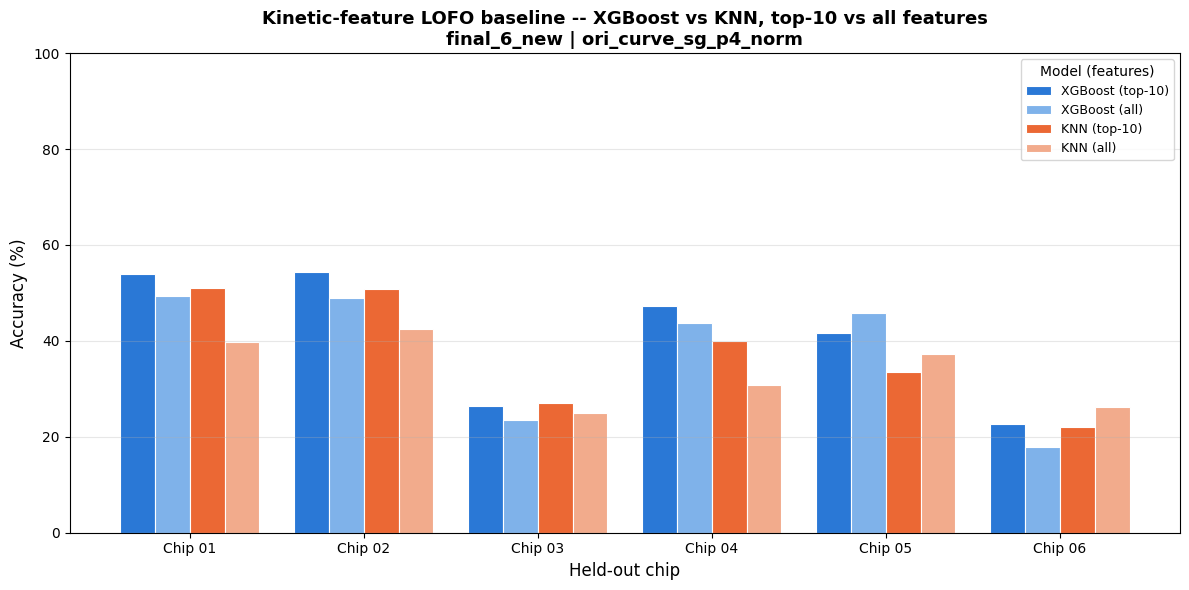

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

combo_order = [("XGB", "top10"), ("XGB", "all"), ("KNN", "top10"), ("KNN", "all")]
combo_labels = {"XGB": "XGBoost", "KNN": "KNN"}
fs_labels = {"top10": "top-10", "all": "all"}
palette = ["#2a78d6", "#7fb2ea", "#eb6834", "#f2ab8c"]

x = np.arange(len(chip_order))
n_combos = len(combo_order)
bar_w = 0.8 / n_combos

for i, (model_name, fs_name) in enumerate(combo_order):
    sub = results_df[(results_df.model == model_name) & (results_df.feature_set == fs_name)]
    sub = sub.set_index("chip_label").reindex(chip_order)
    offset = (i - (n_combos - 1) / 2) * bar_w
    ax.bar(x + offset, sub["accuracy"], width=bar_w, color=palette[i],
          label=f"{combo_labels[model_name]} ({fs_labels[fs_name]})",
          edgecolor="white", linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(chip_order)
ax.set_xlabel("Held-out chip", fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_ylim(0, 100)
ax.set_title(f"Kinetic-feature LOFO baseline -- XGBoost vs KNN, top-10 vs all features\n"
            f"{GROUP_NAME} | {CURVE_TYPE}", fontsize=13, fontweight="bold")
ax.legend(title="Model (features)", fontsize=9, loc="upper right")
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
plt.show()


## 5. Combined-pool 5-fold CV (in-distribution) -- all 4 (model, feature_set) combinations

Well-stratified 5-fold CV over *all six chips pooled together* (no chip held
out) -- every fold's train/test split still keeps each well intact, but train
and test now come from the same six-chip distribution instead of six disjoint
domains. This isolates how much of the LOFO accuracy gap is cross-chip domain
shift vs. plain classification difficulty.

In [8]:
cv_splits = cdt.build_nfold_splits(y_full, well_ids=combined["well_ids"], n_splits=5, random_state=0)
print(f"{len(cv_splits)} combined-pool CV folds: {list(cv_splits.keys())}")

cv_results = []

for fold_label, (train_idx, test_idx) in cv_splits.items():
    top10_cv = cdt._select_top_10_features(X_candidates_clean, y_full, train_idx, fold_label)
    feature_sets = {"top10": top10_cv, "all": config.LD_FEATURES}

    for fs_name, feature_set in feature_sets.items():
        clean_train_idx = _clean_rows(features_df, feature_set, train_idx)
        clean_test_idx = _clean_rows(features_df, feature_set, test_idx)
        n_dropped_train = len(train_idx) - len(clean_train_idx)
        n_dropped_test = len(test_idx) - len(clean_test_idx)

        X_train = features_df.iloc[clean_train_idx][feature_set].to_numpy()
        X_test = features_df.iloc[clean_test_idx][feature_set].to_numpy()
        y_train = y_full[clean_train_idx]
        y_test = y_full[clean_test_idx]

        scaler = StandardScaler().fit(X_train)
        X_train_s = scaler.transform(X_train)
        X_test_s = scaler.transform(X_test)
        train_weight = _class_sample_weight(y_train)

        for model_name, model, weight in [
            ("XGB", xgb.XGBClassifier(**XGB_PARAMS), train_weight),
            ("KNN", KNeighborsClassifier(**KNN_PARAMS), None),
        ]:
            acc, f1, _ = _fit_eval(model, X_train_s, y_train, X_test_s, y_test, sample_weight=weight)
            cv_results.append({
                "fold": fold_label, "model": model_name, "feature_set": fs_name,
                "n_train": len(clean_train_idx), "n_test": len(clean_test_idx),
                "n_dropped_train": n_dropped_train, "n_dropped_test": n_dropped_test,
                "accuracy": acc, "macro_f1": f1,
            })

    print(f"  [+] {fold_label} done")

cv_results_df = pd.DataFrame(cv_results)
cv_results_df.head(8)

5 combined-pool CV folds: ['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4']


  [*] Selected Top 10 Features (fold_0): ['xms', 'Ct', 'first_half_distance', 'second_half_distance', 'Cy0', 'distance_asymmetry_index', 'Cs', 'Fm', 'd2y_xp2', 'd2y_xp1']


  [+] fold_0 done


  [*] Selected Top 10 Features (fold_1): ['xms', 'Ct', 'first_half_distance', 'second_half_distance', 'Cy0', 'distance_asymmetry_index', 'Cs', 'Fm', 'd2y_xp2', 'xp2']


  [+] fold_1 done


...

  [*] Selected Top 10 Features (fold_3): ['Ct', 'xms', 'first_half_distance', 'second_half_distance', 'Cy0', 'distance_asymmetry_index', 'Cs', 'Fm', 'd2y_xp2', 'd2y_xp1']


  [+] fold_3 done


  [*] Selected Top 10 Features (fold_4): ['xms', 'Ct', 'first_half_distance', 'second_half_distance', 'Cy0', 'distance_asymmetry_index', 'Cs', 'Fm', 'd2y_xp2', 'Fb']


  [+] fold_4 done


,fold,model,feature_set,n_train,n_test,n_dropped_train,n_dropped_test,accuracy,macro_f1
0,fold_0,XGB,top10,68244,17076,2080,506,60.740220,59.832727
1,fold_0,KNN,top10,68244,17076,2080,506,57.302647,56.374199
2,fold_0,XGB,all,41975,10387,28349,7195,61.076345,60.847968
3,fold_0,KNN,all,41975,10387,28349,7195,47.453548,46.738673
4,fold_1,XGB,top10,68269,17051,2056,530,60.019940,58.983557
5,fold_1,KNN,top10,68269,17051,2056,530,56.782593,55.778792
6,fold_1,XGB,all,41892,10470,28433,7111,61.805158,61.517119
7,fold_1,KNN,all,41892,10470,28433,7111,47.048711,46.319867


In [9]:
print("Combined-pool 5-fold CV (well-stratified, in-distribution) -- per-fold accuracy (%):\n")
pivot_cv = cv_results_df.pivot_table(index="fold", columns=["model", "feature_set"],
                                     values="accuracy", sort=False)
print(pivot_cv.round(2).to_string())

print("\nMacro Avg +/- std (ddof=1, sample std) across the 5 folds:")
for (model_name, fs_name), grp in cv_results_df.groupby(["model", "feature_set"]):
    mean, std = macro_avg_std(grp, "accuracy")
    print(f"  {model_name:4s} / {fs_name:5s} features: {mean:6.2f}% +/- {std:5.2f}%")

print("\nGeneralization gap: combined-pool 5-fold CV (in-distribution) minus LOFO (cross-chip), Macro Avg (%):")
print(f"  {'Model':4s} {'Feats':6s} {'CV':>8s} {'LOFO':>8s} {'Gap (pp)':>10s}")
for model_name, fs_name in [("XGB", "top10"), ("XGB", "all"), ("KNN", "top10"), ("KNN", "all")]:
    cv_mean, _ = macro_avg_std(cv_results_df[(cv_results_df.model == model_name)
                                             & (cv_results_df.feature_set == fs_name)], "accuracy")
    lofo_mean, _ = macro_avg_std(results_df[(results_df.model == model_name)
                                            & (results_df.feature_set == fs_name)], "accuracy")
    print(f"  {model_name:4s} {fs_name:6s} {cv_mean:8.2f} {lofo_mean:8.2f} {cv_mean - lofo_mean:10.2f}")

Combined-pool 5-fold CV (well-stratified, in-distribution) -- per-fold accuracy (%):

model          XGB    KNN    XGB    KNN
feature_set  top10  top10    all    all
fold                                   
fold_0       60.74  57.30  61.08  47.45
fold_1       60.02  56.78  61.81  47.05
fold_2       59.91  56.82  61.44  47.48
fold_3       60.50  56.77  61.22  47.04
fold_4       60.35  57.89  60.97  47.06

Macro Avg +/- std (ddof=1, sample std) across the 5 folds:
  KNN  / all   features:  47.22% +/-  0.23%
  KNN  / top10 features:  57.11% +/-  0.49%
  XGB  / all   features:  61.30% +/-  0.33%
  XGB  / top10 features:  60.30% +/-  0.34%

Generalization gap: combined-pool 5-fold CV (in-distribution) minus LOFO (cross-chip), Macro Avg (%):
  Model Feats        CV     LOFO   Gap (pp)
  XGB  top10     60.30    41.02      19.28
  XGB  all       61.30    38.23      23.08
  KNN  top10     57.11    37.43      19.68
  KNN  all       47.22    33.59      13.62


## 6. Intra-chip 5-fold CV (per chip, in-distribution) -- all 4 combinations

Same well-stratified 5-fold CV, but run *separately within each chip* (train
and test rows both come from that one chip only). This is the easiest tier --
no cross-chip domain shift at all, not even the partial mixing of section 5's
combined pool -- so together with sections 4-5 it gives a 3-tier difficulty
ladder: intra-chip (easiest) > combined-pool CV > LOFO (hardest, real
deployment scenario).

In [10]:
intra_chip_results = []

for folder_name in folder_names:
    chip_label = short_name(folder_name)
    chip_pos = np.where(combined["dataset_id"] == folder_name)[0]

    features_df_chip = features_df.iloc[chip_pos].reset_index(drop=True)
    X_candidates_chip = X_candidates_clean[chip_pos]
    y_chip = y_full[chip_pos]
    well_ids_chip = combined["well_ids"][chip_pos]

    chip_cv_splits = cdt.build_nfold_splits(y_chip, well_ids=well_ids_chip, n_splits=5, random_state=0)

    for fold_label, (train_idx, test_idx) in chip_cv_splits.items():
        tag = f"{chip_label}/{fold_label}"
        top10_chip = cdt._select_top_10_features(X_candidates_chip, y_chip, train_idx, tag)
        feature_sets = {"top10": top10_chip, "all": config.LD_FEATURES}

        for fs_name, feature_set in feature_sets.items():
            clean_train_idx = _clean_rows(features_df_chip, feature_set, train_idx)
            clean_test_idx = _clean_rows(features_df_chip, feature_set, test_idx)
            n_dropped_train = len(train_idx) - len(clean_train_idx)
            n_dropped_test = len(test_idx) - len(clean_test_idx)

            X_train = features_df_chip.iloc[clean_train_idx][feature_set].to_numpy()
            X_test = features_df_chip.iloc[clean_test_idx][feature_set].to_numpy()
            y_train = y_chip[clean_train_idx]
            y_test = y_chip[clean_test_idx]

            scaler = StandardScaler().fit(X_train)
            X_train_s = scaler.transform(X_train)
            X_test_s = scaler.transform(X_test)
            train_weight = _class_sample_weight(y_train)

            for model_name, model, weight in [
                ("XGB", xgb.XGBClassifier(**XGB_PARAMS), train_weight),
                ("KNN", KNeighborsClassifier(**KNN_PARAMS), None),
            ]:
                acc, f1, _ = _fit_eval(model, X_train_s, y_train, X_test_s, y_test, sample_weight=weight)
                intra_chip_results.append({
                    "chip": folder_name, "chip_label": chip_label, "fold": fold_label,
                    "model": model_name, "feature_set": fs_name,
                    "n_train": len(clean_train_idx), "n_test": len(clean_test_idx),
                    "n_dropped_train": n_dropped_train, "n_dropped_test": n_dropped_test,
                    "accuracy": acc, "macro_f1": f1,
                })

    print(f"  [+] {chip_label} intra-chip CV done")

intra_chip_df = pd.DataFrame(intra_chip_results)
intra_chip_df.head(8)

  [*] Selected Top 10 Features (Chip 01/fold_0): ['Ct', 'xms', 'first_half_distance', 'distance_asymmetry_index', 'second_half_distance', 'Cy0', 'Cs', 'xp2', 'xp1', 'TH']


  [*] Selected Top 10 Features (Chip 01/fold_1): ['Ct', 'xms', 'first_half_distance', 'distance_asymmetry_index', 'second_half_distance', 'Cy0', 'xp1', 'Cs', 'xp2', 'TH']


  [*] Selected Top 10 Features (Chip 01/fold_2): ['Ct', 'xms', 'first_half_distance', 'distance_asymmetry_index', 'second_half_distance', 'Cy0', 'Cs', 'xp2', 'xp1', 'TH']


  [*] Selected Top 10 Features (Chip 01/fold_3): ['Ct', 'xms', 'first_half_distance', 'distance_asymmetry_index', 'second_half_distance', 'Cy0', 'Cs', 'xp2', 'xp1', 'TH']


  [*] Selected Top 10 Features (Chip 01/fold_4): ['Ct', 'xms', 'first_half_distance', 'distance_asymmetry_index', 'second_half_distance', 'Cy0', 'Cs', 'xp2', 'xp1', 'dy_xms']


...

  [*] Selected Top 10 Features (Chip 06/fold_2): ['Ct', 'Cy0', 'Fm', 'd2y_xp2', 'd2y_xp1', 'F_range', 'Fb', 'amplitude', 'Cs', 'xms']


  [*] Selected Top 10 Features (Chip 06/fold_3): ['Ct', 'Cy0', 'Fm', 'd2y_xp2', 'F_range', 'd2y_xp1', 'Fb', 'amplitude', 'Cs', 'xms']


  [*] Selected Top 10 Features (Chip 06/fold_4): ['Ct', 'Cy0', 'Fm', 'd2y_xp2', 'd2y_xp1', 'F_range', 'Fb', 'amplitude', 'Cs', 'xms']


  [+] Chip 06 intra-chip CV done


,chip,chip_label,fold,model,feature_set,n_train,n_test,n_dropped_train,n_dropped_test,accuracy,macro_f1
0,D20260827_E00_C00_F4500KHz_U_DDM_01_final_final,Chip 01,fold_0,XGB,top10,11756,2939,0,0,74.821368,66.441863
1,D20260827_E00_C00_F4500KHz_U_DDM_01_final_final,Chip 01,fold_0,KNN,top10,11756,2939,0,0,68.254508,54.388073
2,D20260827_E00_C00_F4500KHz_U_DDM_01_final_final,Chip 01,fold_0,XGB,all,4534,1074,7222,1865,71.973929,66.483233
3,D20260827_E00_C00_F4500KHz_U_DDM_01_final_final,Chip 01,fold_0,KNN,all,4534,1074,7222,1865,52.886406,40.207691
4,D20260827_E00_C00_F4500KHz_U_DDM_01_final_final,Chip 01,fold_1,XGB,top10,11756,2939,0,0,75.603947,67.762744
5,D20260827_E00_C00_F4500KHz_U_DDM_01_final_final,Chip 01,fold_1,KNN,top10,11756,2939,0,0,67.505954,53.686150
6,D20260827_E00_C00_F4500KHz_U_DDM_01_final_final,Chip 01,fold_1,XGB,all,4464,1144,7292,1795,74.300699,67.510341
7,D20260827_E00_C00_F4500KHz_U_DDM_01_final_final,Chip 01,fold_1,KNN,all,4464,1144,7292,1795,55.244755,41.358334


In [11]:
chip_level = []
for (chip_label, model_name, fs_name), grp in intra_chip_df.groupby(["chip_label", "model", "feature_set"]):
    mean, std = macro_avg_std(grp, "accuracy")
    chip_level.append({"chip_label": chip_label, "model": model_name, "feature_set": fs_name,
                       "fold_mean": mean, "fold_std": std})
chip_level_df = pd.DataFrame(chip_level)

chip_order_full = [short_name(n) for n in folder_names]
print("Intra-chip 5-fold CV -- per-chip mean accuracy (%) across its own 5 folds:\n")
pivot_intra = chip_level_df.pivot_table(index="chip_label", columns=["model", "feature_set"],
                                        values="fold_mean", sort=False)
pivot_intra = pivot_intra.reindex(chip_order_full)
print(pivot_intra.round(2).to_string())

print("\nAcross all 6 chips -- Macro Avg +/- std (ddof=1) of each chip's own 5-fold CV mean:")
for (model_name, fs_name), grp in chip_level_df.groupby(["model", "feature_set"]):
    mean, std = macro_avg_std(grp, "fold_mean")
    print(f"  {model_name:4s} / {fs_name:5s} features: {mean:6.2f}% +/- {std:5.2f}%")

print("\n=== Summary: 3-tier difficulty ladder, Macro Avg accuracy (%) ===")
print(f"  {'Model':4s} {'Feats':6s} {'Intra-chip':>11s} {'Combined-CV':>12s} {'LOFO':>7s}"
     f" {'Gap: CV-LOFO':>14s} {'Gap: Intra-CV':>15s}")
for model_name, fs_name in [("XGB", "top10"), ("XGB", "all"), ("KNN", "top10"), ("KNN", "all")]:
    intra_mean, _ = macro_avg_std(chip_level_df[(chip_level_df.model == model_name)
                                                & (chip_level_df.feature_set == fs_name)], "fold_mean")
    cv_mean, _ = macro_avg_std(cv_results_df[(cv_results_df.model == model_name)
                                             & (cv_results_df.feature_set == fs_name)], "accuracy")
    lofo_mean, _ = macro_avg_std(results_df[(results_df.model == model_name)
                                            & (results_df.feature_set == fs_name)], "accuracy")
    print(f"  {model_name:4s} {fs_name:6s} {intra_mean:11.2f} {cv_mean:12.2f} {lofo_mean:7.2f}"
         f" {cv_mean - lofo_mean:14.2f} {intra_mean - cv_mean:15.2f}")

Intra-chip 5-fold CV -- per-chip mean accuracy (%) across its own 5 folds:

model          KNN           XGB       
feature_set    all  top10    all  top10
chip_label                             
Chip 01      54.68  68.18  72.92  74.53
Chip 02      62.74  78.25  77.44  79.24
Chip 03      47.47  54.43  58.44  56.31
Chip 04      52.33  54.34  61.10  55.89
Chip 05      67.74  71.67  79.36  73.67
Chip 06      55.58  61.17  67.11  65.82

Across all 6 chips -- Macro Avg +/- std (ddof=1) of each chip's own 5-fold CV mean:
  KNN  / all   features:  56.76% +/-  7.32%
  KNN  / top10 features:  64.67% +/-  9.69%
  XGB  / all   features:  69.40% +/-  8.61%
  XGB  / top10 features:  67.58% +/-  9.88%

=== Summary: 3-tier difficulty ladder, Macro Avg accuracy (%) ===
  Model Feats   Intra-chip  Combined-CV    LOFO   Gap: CV-LOFO   Gap: Intra-CV
  XGB  top10        67.58        60.30   41.02          19.28            7.28
  XGB  all          69.40        61.30   38.23          23.08            8.09
 

## 7. LOFO confusion matrices -- XGBoost / top-10 features (best combination)

Per-held-out-chip confusion matrix for the single best-performing LOFO
combination (XGB + top-10 features, 41.02% Macro Avg from section 4),
row-normalized (each row sums to 1, i.e. per-true-class recall) -- same visual
convention as the deep models' LOFO confusion matrices in
`RQ3_04_loco_result_analysis.ipynb`'s `plot_lofo_confusion_matrices`.

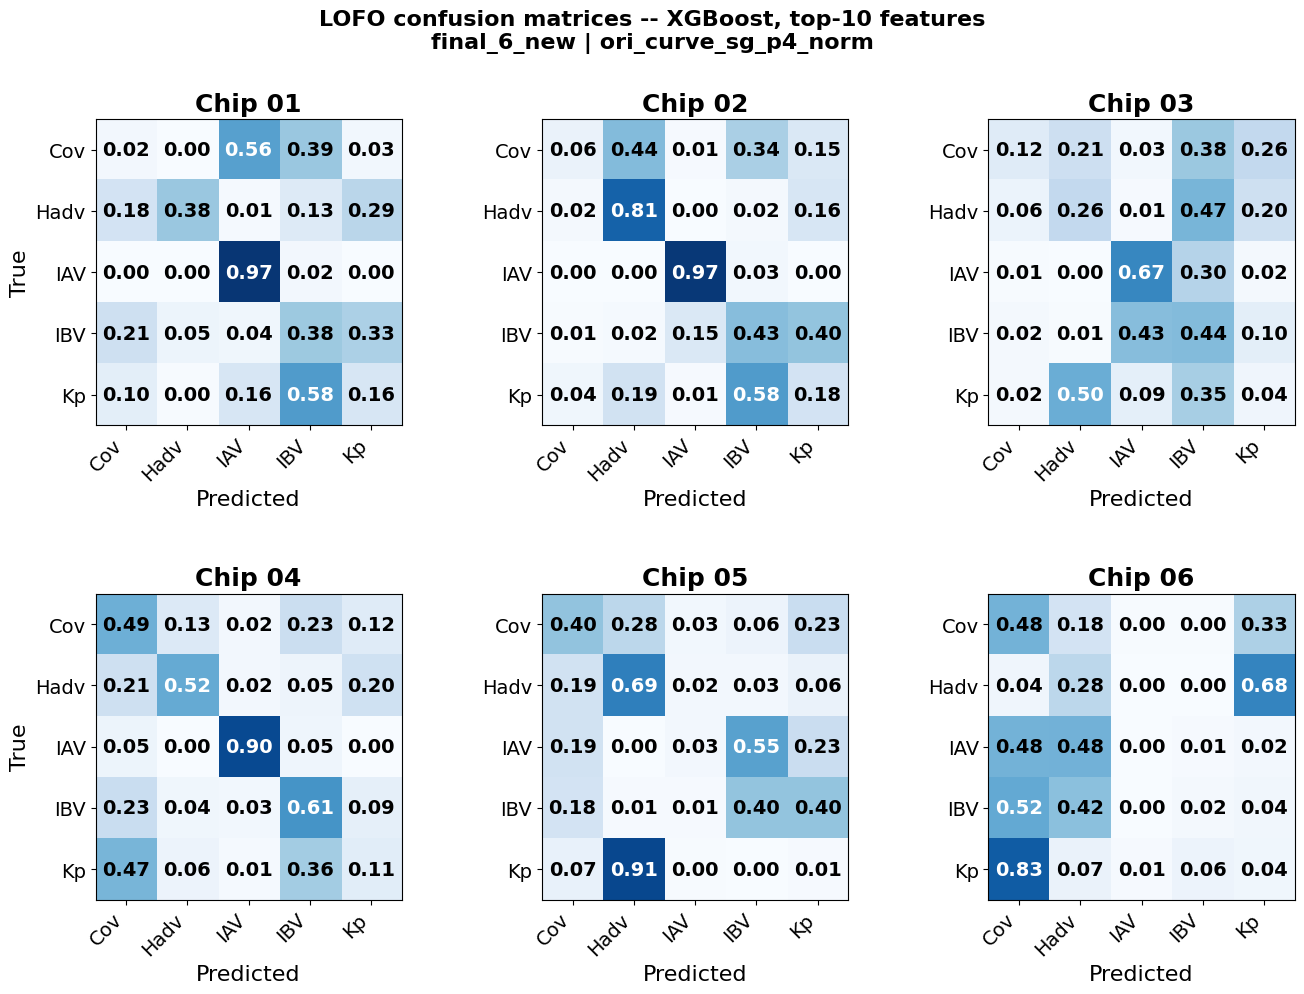

In [12]:
def plot_xgb_confusion_matrices(confusions, class_names, folder_order, ncols=3, figsize_per_cell=(4.6, 4.8)):
    panels = [(folder, confusions[folder]) for folder in folder_order if folder in confusions]
    n = len(panels)
    ncols = min(ncols, n)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_cell[0] * ncols, figsize_per_cell[1] * nrows),
                             squeeze=False)
    for idx, (folder, (y_test, y_pred)) in enumerate(panels):
        ax = axes[idx // ncols, idx % ncols]
        cm = confusion_matrix(y_test, y_pred, labels=range(len(class_names)))
        with np.errstate(invalid="ignore", divide="ignore"):
            cm_disp = cm / cm.sum(axis=1, keepdims=True)
        ax.imshow(cm_disp, cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=14)
        ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names, fontsize=14)
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                val = cm_disp[i, j]
                text = f"{val:.2f}" if not np.isnan(val) else "--"
                color = "white" if (not np.isnan(val) and val > 0.5) else "black"
                ax.text(j, i, text, ha="center", va="center", fontsize=14, fontweight="bold", color=color)
        ax.set_title(short_name(folder), fontsize=18, fontweight="bold")
        ax.set_xlabel("Predicted", fontsize=16)
        if idx % ncols == 0:
            ax.set_ylabel("True", fontsize=16)
    for idx in range(n, nrows * ncols):
        axes[idx // ncols, idx % ncols].axis("off")
    fig.suptitle(f"LOFO confusion matrices -- XGBoost, top-10 features\n{GROUP_NAME} | {CURVE_TYPE}",
                fontsize=16, fontweight="bold", y=1.02)
    fig.tight_layout()
    fig.subplots_adjust(hspace=0.55)
    plt.show()
    plt.close(fig)


xgb_top10_folder_order = [k.replace("lofo_", "") for k in lofo_splits]
plot_xgb_confusion_matrices(xgb_top10_confusions, class_names, xgb_top10_folder_order)